<a href="https://colab.research.google.com/github/Youssef-Chip/lab1/blob/main/lab3/part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U transformers datasets evaluate accelerate torch torchvision pillow

  Using cached pyyaml-6.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached xxhash-3.6.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached propcache-0.4.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (13 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 11.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 9.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 12.4 MB/s  0:00:00 eta 0:00:01
Using cached httpx-0.28.1-p

In [3]:
# Necessary libraries
from transformers import pipeline
from datasets import load_dataset
import evaluate
import time
from PIL import Image

/opt/miniconda3/envs/yc_extractor/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating test split: 100%|██████████| 29/29 [00:00<00:00, 6241.52 examples/s]


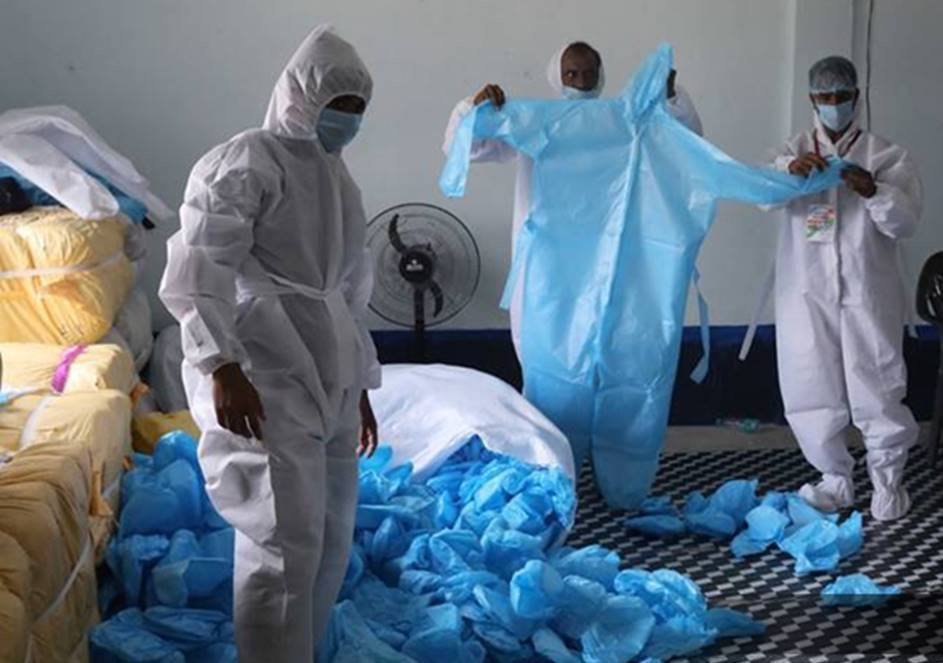

In [4]:
# For the lab, we load the cppe-5 dataset which contains images of medical
# Personal Protective Equipment (PPE) like medical masks, gloves, etc...

# Load only the first 20 images from this dataset
dataset = load_dataset("cppe-5", split="train[:20]")
sample_image = dataset[0]["image"]
sample_image

Initializing models on device 0...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 10948.18it/s]
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Loading weights: 100%|██████████| 590/590 [00:00<00:00, 9572.78it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. 


                ANALYSIS FOR IMAGE 1              


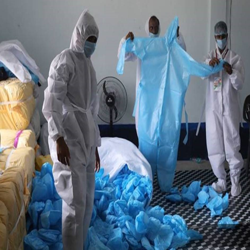


[TASK 1: GENERAL CLASSIFICATION (ViT)]
Label                          | Confidence
---------------------------------------------
plastic bag                    |    65.46%
gasmask, respirator, gas helmet |    10.60%
sleeping bag                   |     5.29%
lab coat, laboratory coat      |     3.55%
shower curtain                 |     1.47%

[TASK 2: ZERO-SHOT CLASSIFICATION (CLIP)]
Label                          | Confidence
---------------------------------------------
medical coveralls              |    82.96%
medical mask                   |     7.61%
surgical gown                  |     4.16%
protective gloves              |     2.93%
medical cap                    |     1.32%

               --- End of Preview ---

                ANALYSIS FOR IMAGE 2              


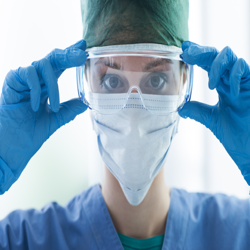


[TASK 1: GENERAL CLASSIFICATION (ViT)]
Label                          | Confidence
---------------------------------------------
gasmask, respirator, gas helmet |    54.75%
lab coat, laboratory coat      |    33.27%
oxygen mask                    |     5.66%
mask                           |     3.20%
ski mask                       |     0.51%

[TASK 2: ZERO-SHOT CLASSIFICATION (CLIP)]
Label                          | Confidence
---------------------------------------------
surgical gown                  |    46.38%
medical mask                   |    27.47%
medical coveralls              |    15.33%
safety goggles                 |     5.22%
medical cap                    |     4.38%

               --- End of Preview ---

                ANALYSIS FOR IMAGE 3              


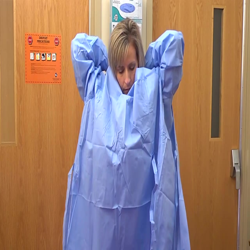


[TASK 1: GENERAL CLASSIFICATION (ViT)]
Label                          | Confidence
---------------------------------------------
lab coat, laboratory coat      |    70.99%
apron                          |     2.01%
shower curtain                 |     1.82%
stethoscope                    |     1.76%
poncho                         |     1.11%

[TASK 2: ZERO-SHOT CLASSIFICATION (CLIP)]
Label                          | Confidence
---------------------------------------------
surgical gown                  |    65.27%
medical coveralls              |    34.30%
face shield                    |     0.35%
medical mask                   |     0.05%
medical cap                    |     0.02%

               --- End of Preview ---

                ANALYSIS FOR IMAGE 4              


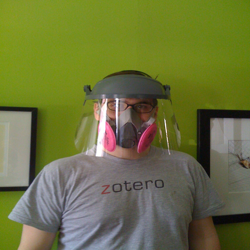


[TASK 1: GENERAL CLASSIFICATION (ViT)]
Label                          | Confidence
---------------------------------------------
gasmask, respirator, gas helmet |    99.76%
oxygen mask                    |     0.13%
mask                           |     0.05%
ski mask                       |     0.00%
snorkel                        |     0.00%

[TASK 2: ZERO-SHOT CLASSIFICATION (CLIP)]
Label                          | Confidence
---------------------------------------------
medical mask                   |    88.44%
face shield                    |    11.01%
safety goggles                 |     0.48%
medical coveralls              |     0.04%
medical cap                    |     0.02%

               --- End of Preview ---

                ANALYSIS FOR IMAGE 5              


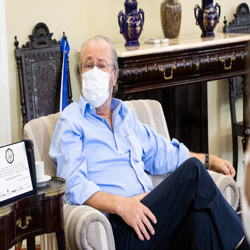


[TASK 1: GENERAL CLASSIFICATION (ViT)]
Label                          | Confidence
---------------------------------------------
neck brace                     |    14.31%
oxygen mask                    |    13.81%
gasmask, respirator, gas helmet |    12.63%
mask                           |     5.15%
notebook, notebook computer    |     2.67%

[TASK 2: ZERO-SHOT CLASSIFICATION (CLIP)]
Label                          | Confidence
---------------------------------------------
medical mask                   |    84.83%
medical cap                    |    14.52%
face shield                    |     0.55%
medical coveralls              |     0.04%
surgical gown                  |     0.03%

               --- End of Preview ---

Truncating output... Processing remaining 15 images in background.

Finished processing all 20 images.


In [9]:
from transformers import pipeline
from datasets import load_dataset
from IPython.display import display

# Load the first 20 images
dataset = load_dataset("cppe-5", split="train[:20]")

# Initialize both Pipelines
print("Initializing models on device 0...")
general_classifier = pipeline(
    "image-classification", 
    model="google/vit-base-patch16-224", 
    device=0
)

zero_shot_classifier = pipeline(
    "zero-shot-image-classification", 
    model="openai/clip-vit-large-patch14", 
    device=0
)

# Expanded labels to ensure we can show a Top 5 for Zero-Shot
ppe_labels = [
    "medical mask", "protective gloves", "medical coveralls", 
    "safety goggles", "face shield", "medical cap", "surgical gown"
]

general_list = []
zs_list = []

# Processing Loop
for i in range(len(dataset)):
    img = dataset[i]["image"]

    # Run Inferences
    # We do this for all 20, but only print for the first 5
    gen_preds = general_classifier(img, top_k=5)
    zs_preds = zero_shot_classifier(img, candidate_labels=ppe_labels) # CLIP returns all by default
    general_list.append(gen_preds)
    zs_list.append(zs_preds)

    # Conditional Printing (Only first 5 images)
    if i < 5:
        print(f"\n" + "="*55)
        print(f"                ANALYSIS FOR IMAGE {i+1}              ")
        print("="*55)
        display(img.resize((250, 250)))

        # --- General Classifier Table ---
        print(f"\n[TASK 1: GENERAL CLASSIFICATION (ViT)]")
        print(f"{'Label':<30} | {'Confidence':<10}")
        print("-" * 45)
        for pred in gen_preds:
            print(f"{pred['label']:30} | {pred['score']*100:>8.2f}%")

        # --- Zero-Shot Classifier Table ---
        print(f"\n[TASK 2: ZERO-SHOT CLASSIFICATION (CLIP)]")
        print(f"{'Label':<30} | {'Confidence':<10}")
        print("-" * 45)
        # zs_preds is already sorted by score; slice for top 5
        for pred in zs_preds[:5]:
            print(f"{pred['label']:30} | {pred['score']*100:>8.2f}%")
            
        print("\n" + " " * 15 + "--- End of Preview ---")
    
    # Progress indicator for the images that aren't printed
    elif i == 5:
        print(f"\nTruncating output... Processing remaining {len(dataset)-5} images in background.")

print("\nFinished processing all 20 images.")

In [6]:
import time

def measure_latency(model_pipeline, image_list):
  """
  Helper function to measure the latency of the model.
  """
  start_time = time.time()
  for image in image_list:
    _ = model_pipeline(image)
  end_time = time.time()

  # Return the average time per image
  return (end_time - start_time) / len(image_list)

In [7]:
# Initializing the second model
print("Downloading and loading ResNet-50...")
#
classifier_resnet = pipeline(
  "image-classification",
  model="microsoft/resnet-50", # A classic CNN model
  device=0
)

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 12694.38it/s]
The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [20]:
import pandas as pd
from IPython.display import display

# 1. Capture Top 5 Predictions for Image 0
test_img = dataset[0]['image']
vit_top_5 = general_classifier(test_img, top_k=5)
resnet_top_5 = classifier_resnet(test_img, top_k=5)

# 2. Format the Top 5 into a single string for the table
vit_preds_str = "\n".join([f"{p['label']} ({p['score']*100:.1f}%)" for p in vit_top_5])
resnet_preds_str = "\n".join([f"{p['label']} ({p['score']*100:.1f}%)" for p in resnet_top_5])

# 3. Define the comparison data
comparison_data = {
    "Metric/Feature": [
        "Model Architecture", 
        "Avg Latency (ms)", 
        "Top 5 Predictions (Image 0)", 
        "Qualitative Note"
    ],
    "ViT (Base)": [
        "Transformer-based", 
        "118.73", 
        vit_preds_str,
        "Focuses on global shapes; misinterpreted PPE as 'plastic bag'."
    ],
    "ResNet-50": [
        "CNN-based", 
        "53.30", 
        resnet_preds_str,
        "Focuses on local textures; correctly associated PPE with 'lab coat'."
    ]
}

# 4. Create DataFrame and Export
df_comparison = pd.DataFrame(comparison_data)

# Set pandas to allow newlines in cells for better display
pd.set_option('display.max_colwidth', None)

print("--- Part C: Final Model Comparison Table ---")
display(df_comparison)

# Save to CSV
df_comparison.to_csv("model_comparison_part_c.csv", index=False)

--- Part C: Final Model Comparison Table ---


,Metric/Feature,ViT (Base),ResNet-50
0,Model Architecture,Transformer-based,CNN-based
1,Avg Latency (ms),118.73,53.30
2,Top 5 Predictions (Image 0),"plastic bag (65.5%)\ngasmask, respirator, gas helmet (10.6%)\nsleeping bag (5.3%)\nlab coat, laboratory coat (3.6%)\nshower curtain (1.5%)","lab coat, laboratory coat (49.6%)\nplastic bag (34.8%)\nponcho (3.4%)\nabaya (1.3%)\nsolar dish, solar collector, solar furnace (1.1%)"
3,Qualitative Note,Focuses on global shapes; misinterpreted PPE as 'plastic bag'.,Focuses on local textures; correctly associated PPE with 'lab coat'.


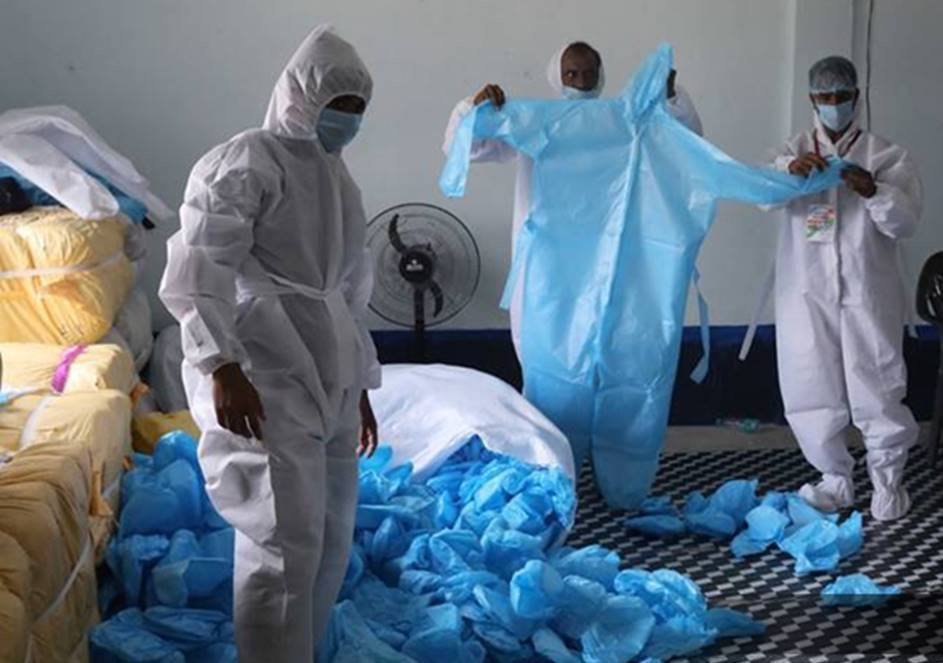

In [21]:
display(dataset[0]['image'])